# 1. Import libraries

In [32]:
# pandas library is used for data manipulation and analysis
# it helps load datasets and work with tabular data using DataFrames
import pandas as pd


# numpy library is used for numerical computations and array operations
# it supports mathematical calculations and handling large multi-dimensional arrays
import numpy as np


# matplotlib is a visualization library used to create graphs and plots
# pyplot module helps generate charts like line plots, histograms, scatter plots, etc.
import matplotlib.pyplot as plt


# seaborn is a statistical visualization library built on top of matplotlib
# it is used to create attractive plots such as heatmaps, pairplots, and distribution plots
import seaborn as sns


# train_test_split is used to divide the dataset into training and testing sets
# GridSearchCV is used to perform hyperparameter tuning using cross-validation
from sklearn.model_selection import train_test_split, GridSearchCV


# StandardScaler standardizes numerical features so that mean becomes 0 and standard deviation becomes 1
# this improves the performance of algorithms like SVM that are sensitive to feature scaling
# LabelEncoder converts categorical labels into numeric values required for machine learning models
from sklearn.preprocessing import StandardScaler, LabelEncoder


# Pipeline is used to combine preprocessing steps and the machine learning model into one workflow
# this ensures transformations like scaling are applied before training the model
from sklearn.pipeline import Pipeline


# SVC (Support Vector Classifier) is the implementation of the Support Vector Machine algorithm
# it finds the optimal hyperplane that separates different classes in a classification problem
from sklearn.svm import SVC


# accuracy_score calculates the overall percentage of correct predictions
# precision_score measures how many predicted positive values are actually correct
# recall_score measures how many actual positive values are correctly identified
# f1_score is the harmonic mean of precision and recall
# classification_report provides a summary of precision, recall, f1-score, and support
# confusion_matrix shows the number of correct and incorrect predictions for each class
# roc_auc_score evaluates the model using the ROC curve and measures classification performance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score)


# PCA (Principal Component Analysis) is a dimensionality reduction technique
# it transforms high-dimensional data into fewer principal components while preserving most variance
# it is useful for visualization and reducing complexity in machine learning models
from sklearn.decomposition import PCA

# 2.Data Loading

In [33]:
# pd.read_csv() is a pandas function used to load a dataset from a CSV (Comma Separated Values) file
# It reads the file "Pharama_Industry.csv" and stores it in a DataFrame called 'df'
# A DataFrame is a table-like structure with rows and columns used for data analysis
df = pd.read_csv("Pharma_Industry.csv")

In [34]:
# df displays the dataset
# it shows rows and columns of the loaded DataFrame so we can inspect the data
df

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1
...,...,...,...,...,...,...
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393,0
496,0.551476,1.714321,0.340589,1.712558,-0.496315,1
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838,1
498,1.661259,0.245759,-0.457096,0.633355,0.657413,0


# 3.Data Preview

In [35]:
# df.head() displays the first 5 rows of the dataset
# It is used to quickly inspect the dataset structure, column names, and sample values
# This helps verify that the dataset was loaded correctly
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


# 4. Dataset Dimension Check

In [36]:
# shape returns the dimensions of the DataFrame
# it shows the total number of rows and columns in the dataset
# useful to quickly understand dataset size before analysis
df.shape


(500, 6)

# 5.Feature Identification

In [37]:
# columns returns the names of all columns in the DataFrame
# useful to understand the available features in the dataset
df.columns

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

# 6.Data Type Inspection

In [38]:
# dtypes shows the data type of each column (int, float, object, etc.)
# helps identify numerical and categorical variables for preprocessing
df.dtypes

Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg)    float64
Heart Rate (BPM)                  float64
Liver Toxicity Index (U/L)        float64
Blood Glucose Level (mg/dL)       float64
Drug Response                       int64
dtype: object

# 7.Missing Value Analysis

In [39]:
# isna() checks for missing values (NaN) in the dataset
# sum() counts the number of missing values in each column
# this helps identify columns that need data cleaning or imputation
df.isna().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

# 8.Duplicate Data Check

In [40]:
# duplicated() checks for duplicate rows in the dataset
# sum() counts how many duplicate records exist
# this helps identify repeated entries that may need to be removed
df.duplicated().sum()

0

# 9. Feature Distribution Analysis (Histograms)

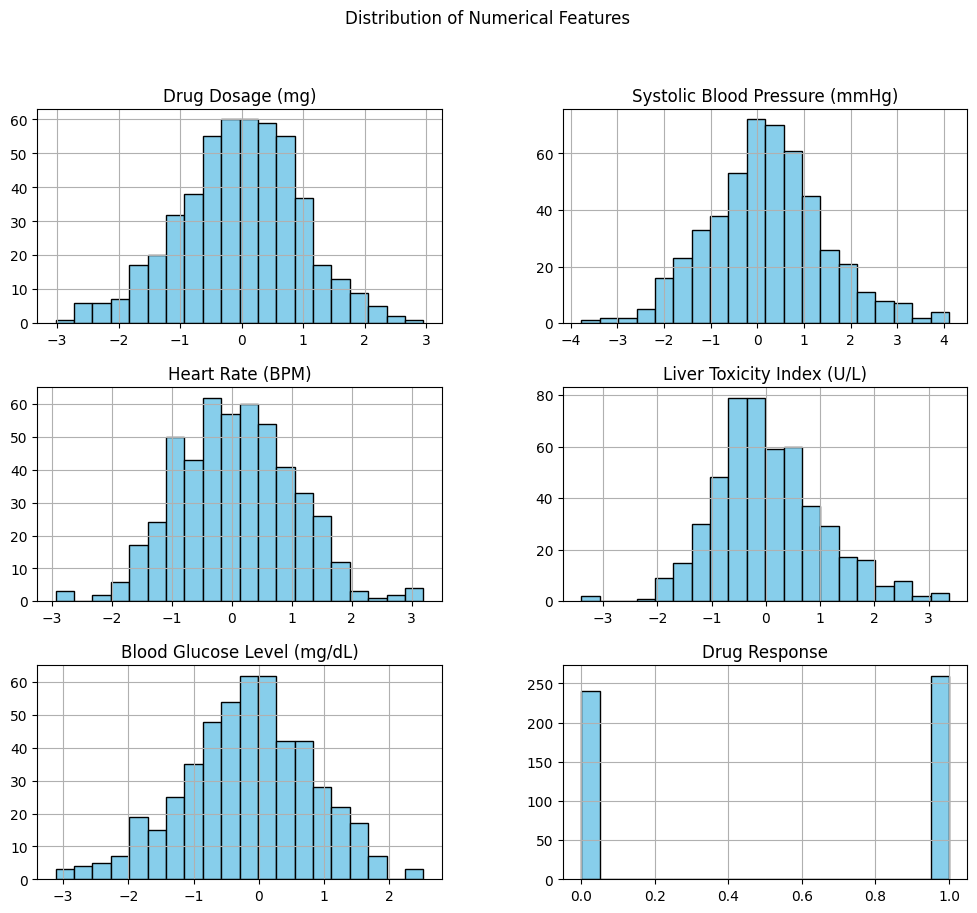

In [41]:
# df.hist() automatically creates histogram plots for all numerical columns in the DataFrame
# histograms show how data values are distributed across different ranges
# figsize=(12,10) sets the size of the figure to make the plots larger and clearer
# bins=20 divides the data into 20 intervals to visualize frequency distribution
# color='skyblue' sets the color of the bars in the histogram
# edgecolor='black' adds a border color around each bar for better visibility
df.hist(figsize=(12, 10), bins=20, color='skyblue', edgecolor='black')


# suptitle() adds a main title for the entire figure containing multiple plots
# here it describes that the plots show distribution of numerical features
plt.suptitle("Distribution of Numerical Features")


# show() displays the generated plots
# it renders all histogram graphs in the output
plt.show()

# 10. Outlier Detection Using Boxplots

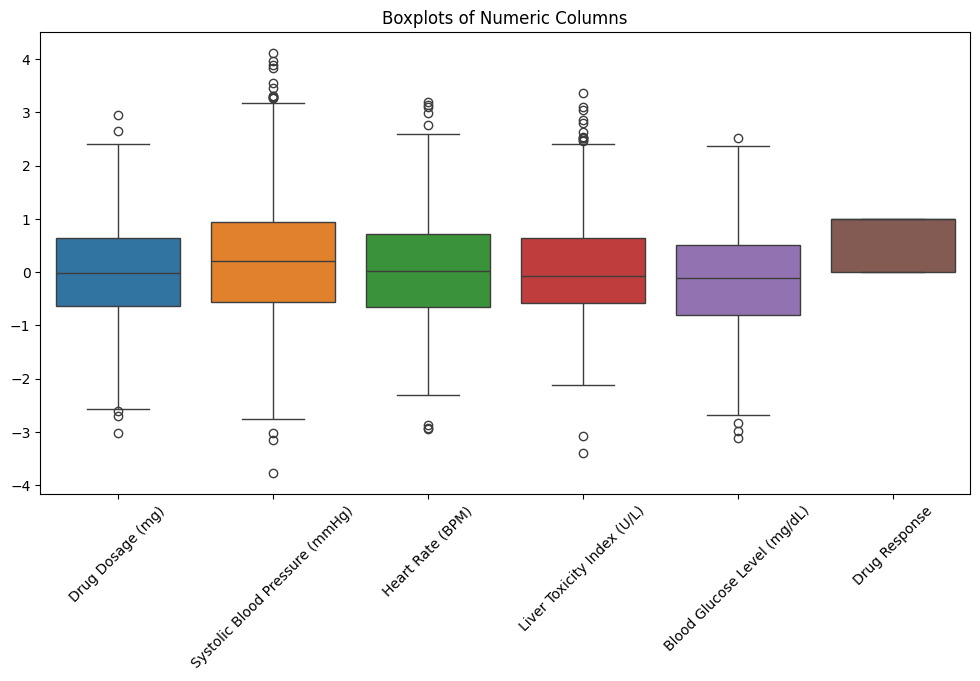

In [42]:
# create a new figure for plotting
# figsize=(12,6) sets the width and height of the plot so it is clearly visible
plt.figure(figsize=(12, 6))


# sns.boxplot() creates boxplots for the selected numerical columns
# boxplots help identify outliers, median, and spread of the data
# df.select_dtypes(include=['float64','int64']) selects only numeric columns from the dataset
# this ensures boxplots are generated only for numerical features
sns.boxplot(data=df.select_dtypes(include=['float64', 'int64']))


# title() adds a title to the plot describing what the visualization represents
plt.title("Boxplots of Numeric Columns")


# xticks(rotation=45) rotates the x-axis labels by 45 degrees
# this makes long column names easier to read
plt.xticks(rotation=45)


# show() displays the boxplot visualization
plt.show()

# 11.Feature Correlation Analysis (Heatmap)

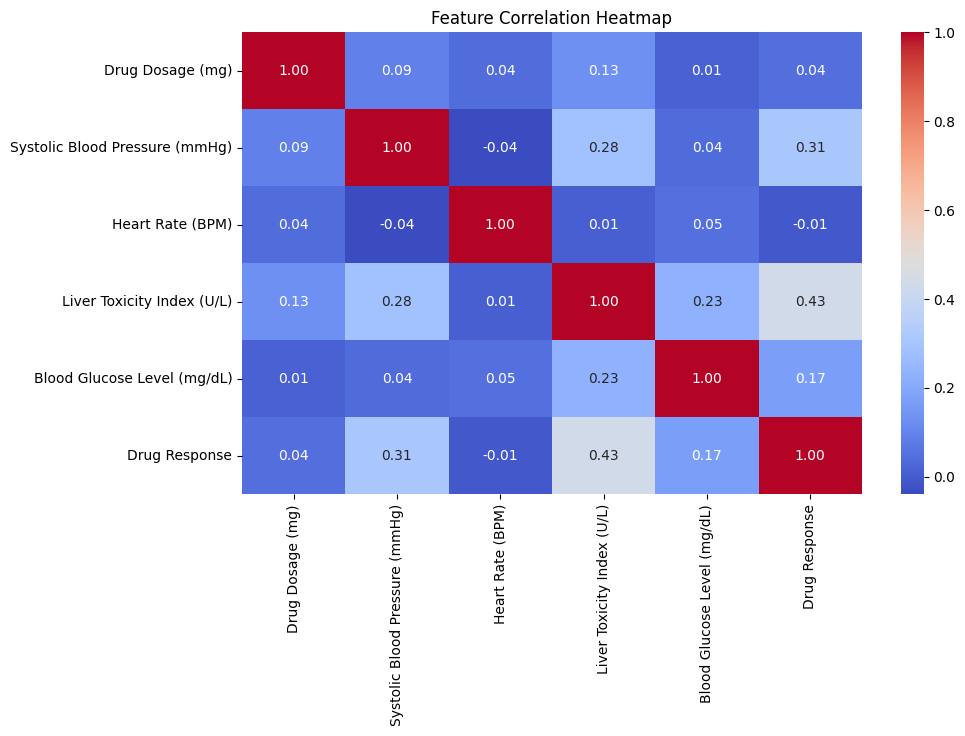

In [43]:
# create a new figure for plotting
# figsize=(10,6) sets the width and height of the heatmap for better visibility
plt.figure(figsize=(10, 6))


# sns.heatmap() creates a heatmap visualization of correlations between features
# df.corr() calculates the correlation matrix between numerical columns
# annot=True displays the correlation values inside each cell of the heatmap
# cmap='coolwarm' sets the color scheme (blue = negative correlation, red = positive correlation)
# fmt=".2f" formats the correlation values to show only 2 decimal places
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")


# adds a title describing the visualization
plt.title("Feature Correlation Heatmap")


# displays the heatmap
plt.show()

# 12.Separate Features and Target Variable

In [44]:
# drop() removes the specified column from the dataset
# columns='Drug Response' removes the target column from the DataFrame
# the remaining columns become the input features used to train the model
features = df.drop(columns='Drug Response')


# df['Drug Response'] selects the target column from the dataset
# this column represents the output variable the model will predict
# here it indicates whether the drug response is positive or negative
target = df['Drug Response']

# 13.Train-Test Split

In [45]:
# train_test_split() divides the dataset into training and testing sets
# features are the input variables (independent variables)
# target is the output variable (dependent variable to be predicted)
# test_size=0.2 means 20% of the data is used for testing and 80% for training
# random_state=42 ensures the split is reproducible (same result every time the code runs)
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# 14. Check Training and Testing Data Shapes

In [46]:
# print() displays the output in the console

# x_train.shape shows the number of rows and columns in the training feature dataset
# it tells how many samples and features are used to train the model
print(x_train.shape)


# x_test.shape shows the number of rows and columns in the testing feature dataset
# this data is used to evaluate the model performance
print(x_test.shape)


# y_train.shape shows the number of target values in the training dataset
# these values correspond to the labels for x_train
print(y_train.shape)


# y_test.shape shows the number of target values in the testing dataset
# these values are used to compare with model predictions
print(y_test.shape)

(400, 5)
(100, 5)
(400,)
(100,)


# 15.Feature Scaling

In [47]:
# Used to bring all features to the same scale (mean = 0, std = 1)
scaler = StandardScaler()

# Fit scaler on training data and scale it
x_train_scaled = scaler.fit_transform(x_train)

# Use the same scaler to scale test data
x_test_scaled = scaler.transform(x_test)

# 16.Data Visualization

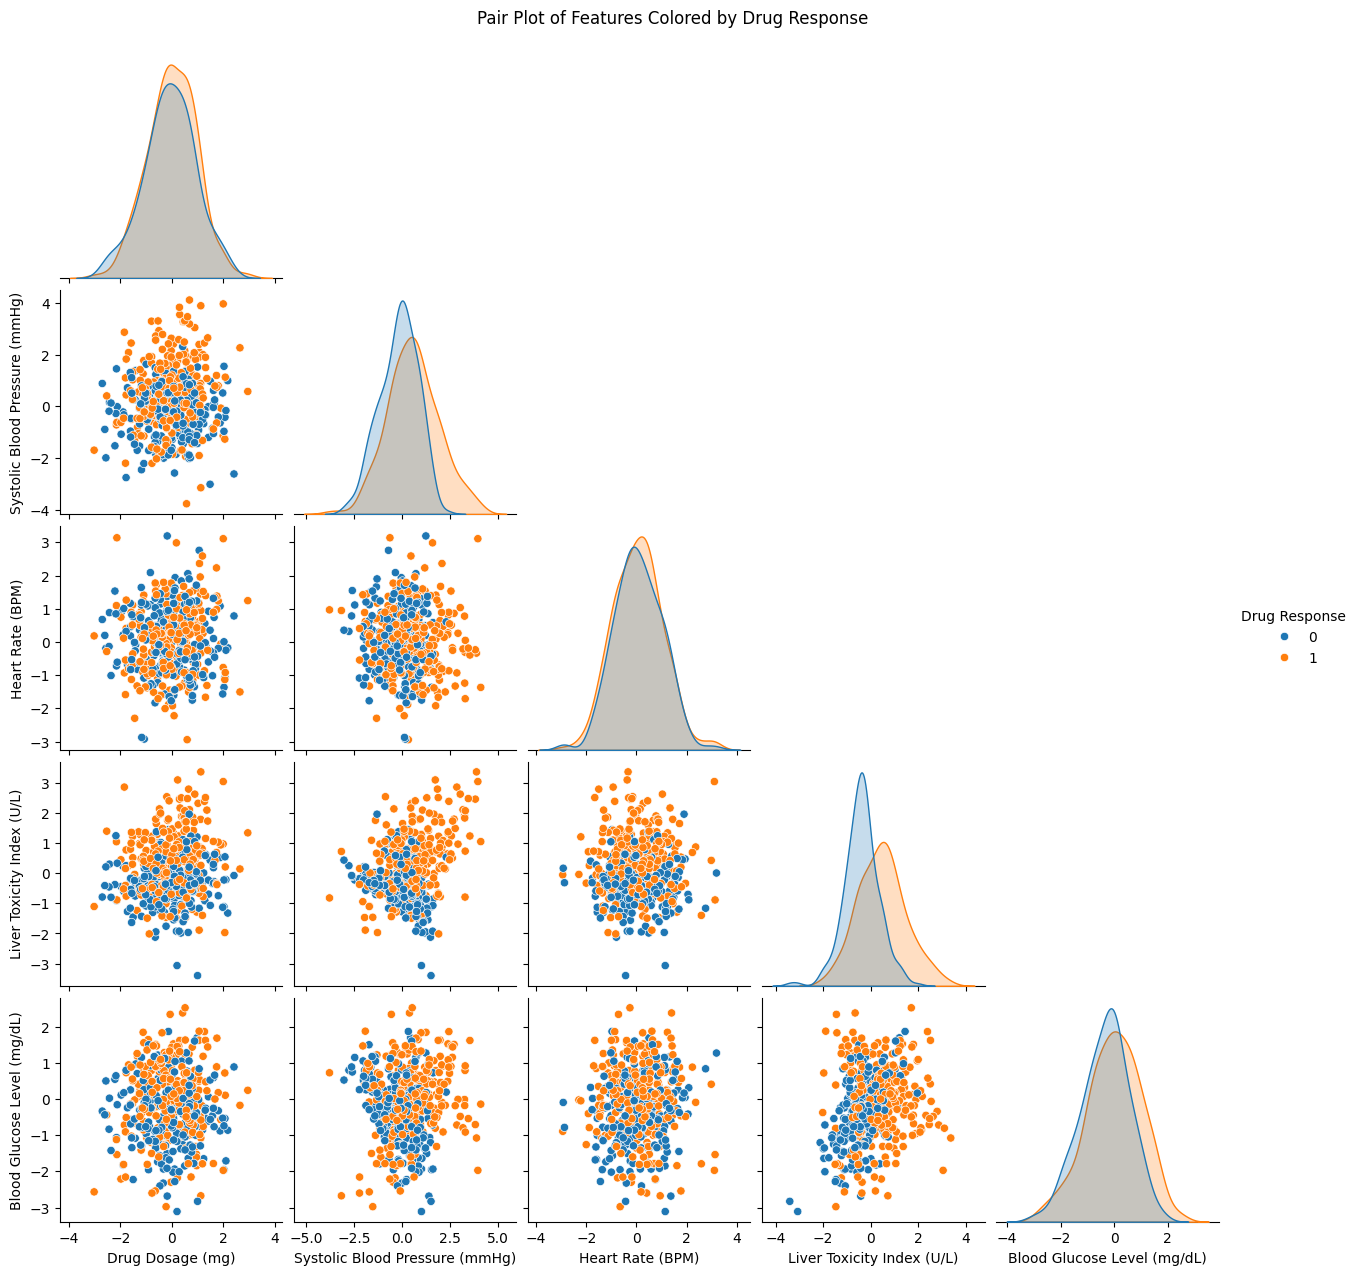

In [48]:
# Pair Plot
# Used to visualize relationships between all numerical features
# and see how they vary for different Drug Response classes.

sns.pairplot(df, hue='Drug Response', diag_kind='kde', corner=True)

# Title for the pair plot
plt.suptitle("Pair Plot of Features Colored by Drug Response", y=1.02)

plt.show()


# 17. Scatter Plot

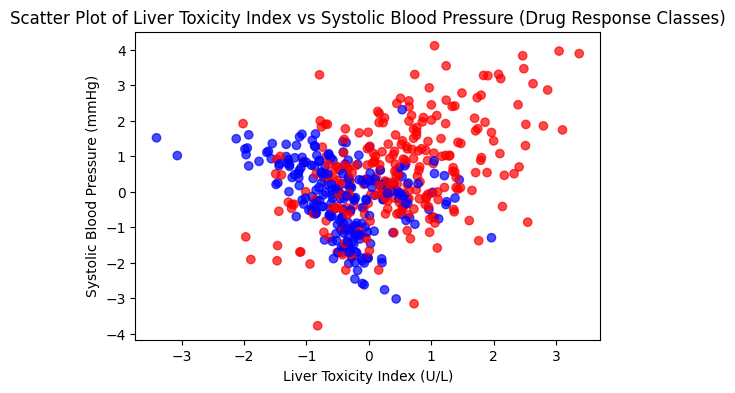

In [49]:
# Scatter Plot
# Used to see the relationship between two features

x_col = "Liver Toxicity Index (U/L)"
y_col = "Systolic Blood Pressure (mmHg)"

plt.figure(figsize=(6,4))

# Scatter plot with colors representing Drug Response classes
plt.scatter(df[x_col], df[y_col],
            c=df['Drug Response'].astype('category').cat.codes,
            cmap='bwr', alpha=0.7)

# Axis labels
plt.xlabel(x_col)
plt.ylabel(y_col)

# Title of the plot
plt.title("Scatter Plot of Liver Toxicity Index vs Systolic Blood Pressure (Drug Response Classes)")

plt.show()

# 18. Class Distribution Plot

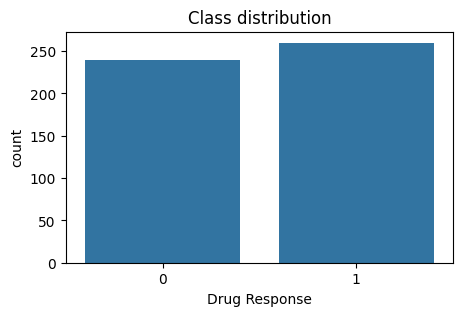

In [50]:
# Shows number of samples in each class
# Helps detect class imbalance.
plt.figure(figsize=(5,3))
sns.countplot(x=target)
plt.title("Class distribution")
plt.show()

# 19.Initialize SVM Model

In [51]:
# Initialize SVM
svm_model = SVC(kernel='linear', random_state=42)

# 20. Train Model

In [52]:
# Train
svm_model.fit(x_train_scaled, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


# 21.Prediction

In [53]:
y_pred = svm_model.predict(x_test_scaled)

# 22.Model Evaluation

In [54]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.78
Precision: 0.84
Recall: 0.75
F1-score: 0.7924528301886793

Classification report:
               precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100



# 23.Confusion Matrix

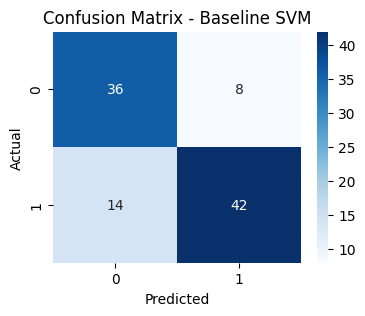

In [55]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline SVM")
plt.show()

# 24.PCA Dimensionality Reduction

In [56]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_test_scaled)

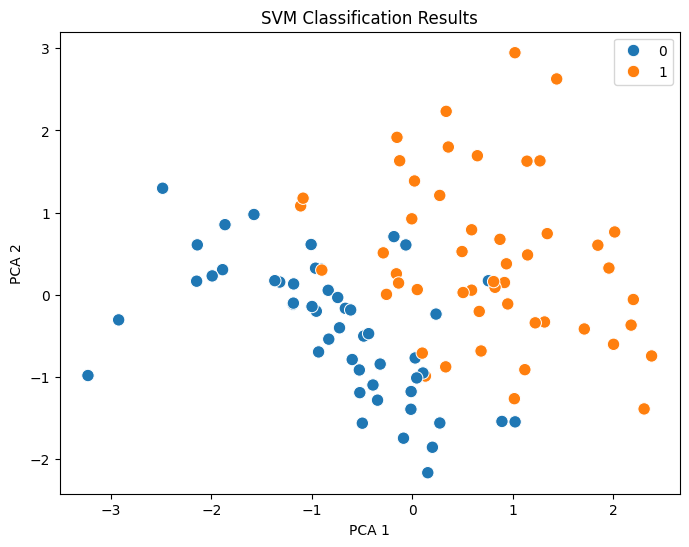

In [57]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=x_pca[:,0], y=x_pca[:,1], hue=y_pred, s=80)#PCA Visualization
plt.title("SVM Classification Results")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# 25.Hyperparameter Tuning

In [58]:
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

# 26.GridSearchCV

In [59]:
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(x_train_scaled, y_train)

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [60]:
print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Accuracy: 0.7300000000000001


# 27.Kernel Comparison

In [61]:
kernels = ['linear', 'poly', 'rbf']
for k in kernels:
    model = SVC(kernel=k)
    model.fit(x_train_scaled, y_train)
    pred = model.predict(x_test_scaled)
    print(f"Kernel: {k} → Accuracy: {accuracy_score(y_test, pred):.3f}")

Kernel: linear → Accuracy: 0.780
Kernel: poly → Accuracy: 0.710
Kernel: rbf → Accuracy: 0.840


#### Support Vector Machine (SVM) was used to classify drug responses. The dataset was analyzed using EDA techniques such as histograms, boxplots, heatmaps, and scatter plots to understand the data. After preprocessing and feature scaling, the data was split into training and testing sets. The SVM model was trained and evaluated using accuracy, precision, recall, and F1-score. GridSearchCV was used to improve the model performance, and PCA helped visualize the results. Overall, the model successfully predicted drug responses based on the given features.